In [1]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.7 MB/s eta 0:00:00


## Evaluating Model efficiency

In [2]:
import os
import time
import numpy as np
import cv2
from ultralytics import YOLO
from dataclasses import dataclass, field
from typing import List, Dict
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = "/kaggle/input/datasets/trietdeptrai/shanghaitech/shanghaitech"
FRAME_PATH = os.path.join(BASE_PATH,'testing/frames')
FRAME_MASK_PATH = os.path.join(BASE_PATH,'testing/test_frame_mask')
PIXEL_MASK_PATH = os.path.join(BASE_PATH,'testing/test_pixel_mask')

CLASSES = [0,1,3]
CONF_THRESHOLD = 0.4
DEVICE = "cuda"    
N_SCENES = 5  
MODELS = {
    "YOLOv8n": "yolov8n.pt",
    "YOLOv8s": "yolov8s.pt",
    "YOLOv8m": "yolov8m.pt",
    "YOLOv8l": "yolov8l.pt",
    "YOLO11n": "yolo11n.pt",
    "YOLO11s": "yolo11s.pt",
    "YOLO11m": "yolo11m.pt",
    "YOLO11l": "yolo11l.pt",
    "YOLO26n": "yolo26n.pt"
}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
def load_scene_data(scene_id): 
    frame_dir = os.path.join(FRAME_PATH,scene_id)
    frame_files = sorted(os.listdir(frame_dir))
    fm = np.load(os.path.join(FRAME_MASK_PATH,f"{scene_id}.npy"))
    pm = np.load(os.path.join(PIXEL_MASK_PATH,f"{scene_id}.npy"))
    return frame_dir, frame_files, fm, pm

In [4]:
def check_hit(boxes_xyxy, gt_mask): 
    if len(boxes_xyxy) == 0: 
        return False
    H,W = gt_mask.shape
    for box in boxes_xyxy: 
        x1, y1, x2, y2 = box.astype(int)
        x1, y1 = max(0,x1), max(0,y1)
        x2, y2 = min(W,x2), min(H,y2)
        roi = gt_mask[y1:y2, x1:x2].sum()
        if roi > 0: 
            return True
    return False

In [5]:
def benchmark(model,scene_id): 
    frame_dir, frame_files, fm, pm = load_scene_data(scene_id)
    latencies = []
    hits = []
    is_anomalies = []
    for i, frame_name in enumerate(frame_files): 
        frame = cv2.imread(os.path.join(frame_dir,frame_name))
        start = time.perf_counter()
        result = model(frame, classes=[0, 1, 3],verbose=False)
        end = time.perf_counter()
        duration = end - start
        boxes = result[0].boxes.xyxy.cpu().numpy()
        is_anomaly = fm[i] > 0      # frame thứ i có anomaly không
        hit = check_hit(boxes, pm[i]) if is_anomaly else False
        latencies.append(duration)
        is_anomalies.append(is_anomaly)
        hits.append(hit)
    return latencies, is_anomalies, hits

In [6]:
def calc_metrics(latencies, is_anomalies, hits):
    fps = 1 / float(np.mean(latencies))
    avg_latencies_ms = np.mean(latencies) *1000
    anomaly_count = len([ab for ab in is_anomalies if ab == True])
    detection_rate =100 * len([hit for is_anomaly, hit in zip(is_anomalies, hits) if is_anomaly and hit]) / anomaly_count if anomaly_count > 0 else 0.0
    return fps, avg_latencies_ms, detection_rate

In [7]:
print(MODELS)

{'YOLOv8n': 'yolov8n.pt', 'YOLOv8s': 'yolov8s.pt', 'YOLOv8m': 'yolov8m.pt', 'YOLOv8l': 'yolov8l.pt', 'YOLO11n': 'yolo11n.pt', 'YOLO11s': 'yolo11s.pt', 'YOLO11m': 'yolo11m.pt', 'YOLO11l': 'yolo11l.pt', 'YOLO26n': 'yolo26n.pt'}


In [8]:
import torch
import gc
torch.cuda.empty_cache() # giải phóng gpu vram
gc.collect() # dọn nốt phần còn lại

7743

In [9]:
import torch
import gc
for model_name, model_path in MODELS.items():
    print("Go go")
    model = YOLO(model_path)
    
    all_latencies = []
    all_is_anomalies = []
    all_hits = []
    
    for scene_id in os.listdir(FRAME_PATH):
        latencies, is_anomalies, hits = benchmark(model,scene_id)
        all_latencies.extend(latencies)
        all_is_anomalies.extend(is_anomalies)
        all_hits.extend(hits)
    print(type(all_latencies[0]))
    print(all_latencies[:5])
    fps, avg_ms, dr = calc_metrics(all_latencies,all_is_anomalies,all_hits)
    print(f"{model_name} | FPS: {fps:.1f} | Latency: {avg_ms:.1f}ms | Detection Rate: {dr:.1f}%")
    del model # xóa object khởi vram
    torch.cuda.empty_cache() # giải phóng gpu vram
    gc.collect() # dọn nốt phần còn lại

Go go
<class 'float'>
[2.794071980999888, 0.00903976200015677, 0.0089119109998137, 0.008318376000261196, 0.008791725000264705]
YOLOv8n | FPS: 106.7 | Latency: 9.4ms | Detection Rate: 87.7%
Go go
<class 'float'>
[0.19639467800016064, 0.015088700999967841, 0.01311119999991206, 0.012965683999937028, 0.013061716000265733]
YOLOv8s | FPS: 113.5 | Latency: 8.8ms | Detection Rate: 91.7%
Go go
<class 'float'>
[0.3326478529997985, 0.022079917000155547, 0.02184066600011647, 0.021578615000180434, 0.02190289700001813]
YOLOv8m | FPS: 66.6 | Latency: 15.0ms | Detection Rate: 93.3%
Go go
<class 'float'>
[0.46513336400039407, 0.024389091000557528, 0.02560955399985687, 0.024149556000338634, 0.02686554200045066]
YOLOv8l | FPS: 38.4 | Latency: 26.0ms | Detection Rate: 93.5%
Go go
<class 'float'>
[0.1881397549996109, 0.010196602000178245, 0.010139525000340655, 0.009761538999555341, 0.009746953000103531]
YOLO11n | FPS: 92.4 | Latency: 10.8ms | Detection Rate: 89.3%
Go go
<class 'float'>
[0.16522210800030734

## Model and Return Format

In [10]:
from ultralytics import YOLO

from IPython.display import display, Image
model = YOLO('yolov8x')
model.info()

YOLOv8x summary: 209 layers, 68,229,648 parameters, 0 gradients, 258.5 GFLOPs


(209, 68229648, 0, 258.5472512)

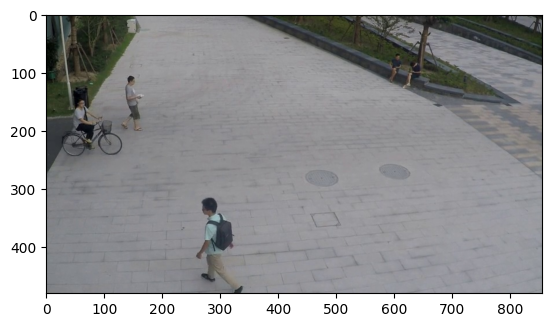

In [11]:
import cv2
import os
frame_dir, frame_files, fm, pm = load_scene_data('01_0014')
img = cv2.imread(os.path.join(frame_dir,frame_files[156]))
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [12]:
from typing import List, Tuple
import numpy as np
from dataclasses import dataclass
@dataclass
class YoloOutput:
    frame_id: int
    boxes_xyxy: np.ndarray
    confidences: np.ndarray
    class_ids: np.ndarray
    centers: List[Tuple[float, float]]

In [13]:
CONF_THRESHOLD = 0.4
def detect(model, frame, frame_ids): 
    results = model(frame, classes=[0, 1, 3], conf=CONF_THRESHOLD, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    conf = results[0].boxes.conf.cpu().numpy()
    class_ids = results[0].boxes.cls.cpu().numpy()
    centers = []
    for box in boxes: 
        x1, y1, x2, y2 = box
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        centers.append((cx,cy))
    output = YoloOutput(
        frame_id = frame_ids, 
        boxes_xyxy = boxes, 
        confidences = conf, 
        class_ids = class_ids, 
        centers = centers
    )
    return output

In [14]:
output = detect(model,img,156)

In [15]:
vars(output)

{'frame_id': 156,
 'boxes_xyxy': array([[     257.97,      314.95,       340.9,      479.31],
        [     27.142,      176.85,      131.78,      244.45],
        [     129.24,      105.46,      168.99,      201.41],
        [     44.908,      146.81,      97.412,      223.51],
        [     591.44,      67.972,      613.73,      119.02],
        [     615.19,      81.269,      647.03,      126.89]], dtype=float32),
 'confidences': array([    0.92126,     0.89785,     0.88778,     0.84788,     0.81226,     0.78542], dtype=float32),
 'class_ids': array([          0,           1,           0,           0,           0,           0], dtype=float32),
 'centers': [(np.float32(299.43665), np.float32(397.1308)),
  (np.float32(79.46174), np.float32(210.64868)),
  (np.float32(149.11453), np.float32(153.43648)),
  (np.float32(71.15987), np.float32(185.15717)),
  (np.float32(602.5868), np.float32(93.496414)),
  (np.float32(631.1132), np.float32(104.0797))]}